In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import warnings
from multiprocessing import Pool, cpu_count
from functools import partial

import multiprocess as mp
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from cachetools import cached
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

In [2]:
BASE_DIR = "./Dataset"
LANGUAGES = ("German", "Italian", "Korean", "Spanish")


@cached(cache={})
def load_audio(file_path: str, sr=16000):
    signal, sample_rate = librosa.load(file_path, sr=sr)
    return signal, sample_rate


def load_df() -> pd.DataFrame:
    return_data = []
    for language in LANGUAGES:
        path = os.path.join(BASE_DIR, language)
        genders = os.listdir(path)
        for gender in genders:
            dir_path = os.path.join(path, gender)
            if not os.path.isdir(dir_path):
                continue
            audio_files = os.listdir(dir_path)
            for audio_file in audio_files:
                audio_path = os.path.join(dir_path, audio_file)
                return_data.append(
                    {
                        "language": language,
                        "gender": gender,
                        "audio_path": audio_path,
                    }
                )
    return pd.DataFrame(return_data)


@cached(cache={})
def get_mfccs(path: str, n_features=13):
    audio, sr = load_audio(path)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_features)
    mfccs = np.mean(mfccs.T, axis=0)
    return mfccs


@cached(cache={})
def get_mel_spectrogram(path: str, n_features=128):
    audio, sr = load_audio(path)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_features)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_db = np.mean(mel_spec_db.T, axis=0)
    return mel_spec_db



def run_parallel(func, paths, n_features):
    n_jobs = cpu_count() - 1
    if n_jobs < 1:
        n_jobs = 1
    with mp.Pool(processes=n_jobs) as pool:
        results = list(
            tqdm(
                pool.imap(partial(func, n_features=n_features), paths),
                total=len(paths),
                desc=f"Extracting features with {func.__name__}",
            )
        )
    results = [r for r in results if r is not None]
    return np.array(results)



df = load_df()
print(f"df.shape = {df.shape}")
print(df["language"].value_counts())

df.shape = (720, 3)
language
German     180
Italian    180
Korean     180
Spanish    180
Name: count, dtype: int64


In [3]:
audio_paths = df["audio_path"].tolist()
X_mfccs = run_parallel(get_mfccs, audio_paths, n_features=13)
X_mel_specs = run_parallel(get_mel_spectrogram, audio_paths, n_features=128)

X_combined = np.hstack([X_mfccs, X_mel_specs])

label_encoder = LabelEncoder()
y_true = label_encoder.fit_transform(df["language"])

print(f"{X_mfccs.shape = }")
print(f"{X_mel_specs.shape = }")
print(f"{X_combined.shape = }")
print(f"{y_true.shape = }")
print(f"Number of classes: {len(np.unique(y_true))}")
print(
    f"label_encoder: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}"
)

Extracting features with get_mel_spectrogram: 100%|██████████| 720/720 [00:30<00:00, 23.52it/s]


X_mfccs.shape = (720, 13)
X_mel_specs.shape = (720, 128)
X_combined.shape = (720, 141)
y_true.shape = (720,)
Number of classes: 4
label_encoder: {'German': np.int64(0), 'Italian': np.int64(1), 'Korean': np.int64(2), 'Spanish': np.int64(3)}


In [4]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)
print(f"X_scaled.shape = {X_scaled.shape}")

X_scaled.shape = (720, 141)


Finding optimal number of clusters...
n_clusters=2: Silhouette Score=0.3052, Inertia=68106.60
n_clusters=3: Silhouette Score=0.2814, Inertia=52850.66
n_clusters=4: Silhouette Score=0.2558, Inertia=46053.22
n_clusters=5: Silhouette Score=0.2550, Inertia=41255.80
n_clusters=6: Silhouette Score=0.2570, Inertia=36803.24
n_clusters=7: Silhouette Score=0.2805, Inertia=32713.95
n_clusters=8: Silhouette Score=0.2937, Inertia=30534.69
n_clusters=9: Silhouette Score=0.2966, Inertia=28647.57
n_clusters=10: Silhouette Score=0.2971, Inertia=26826.33


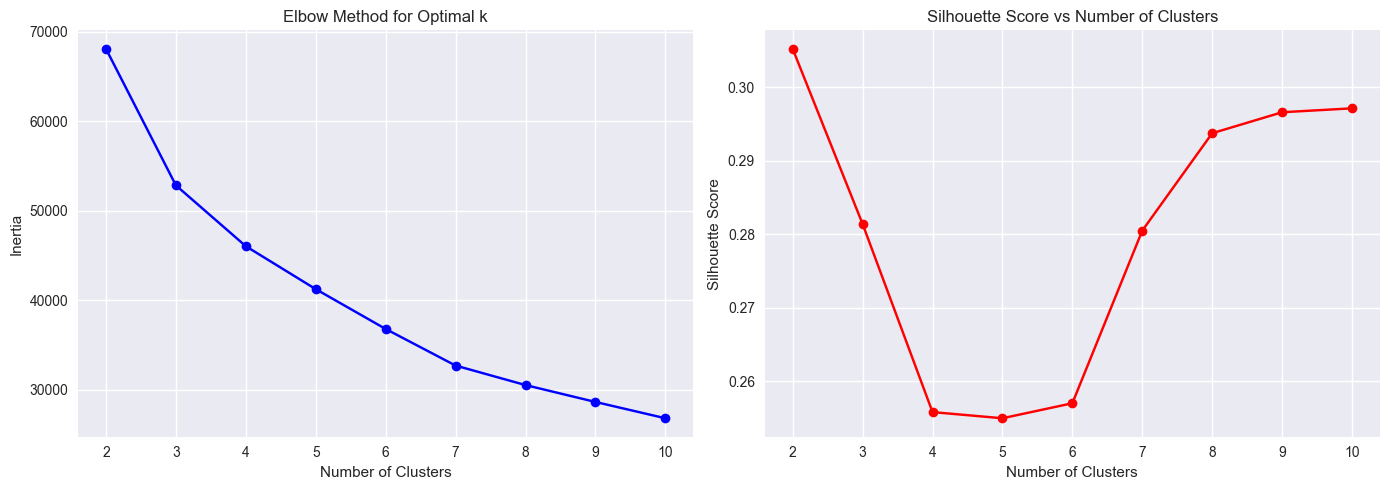


Using 4 clusters for clustering algorithms


In [5]:
n_clusters_range = range(2, 11)
kmeans_scores = []
silhouette_scores = []

print("Finding optimal number of clusters...")
for n_clusters in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    kmeans_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_avg)
    print(
        f"n_clusters={n_clusters}: Silhouette Score={silhouette_avg:.4f}, Inertia={kmeans.inertia_:.2f}"
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(n_clusters_range, kmeans_scores, "bo-")
ax1.set_xlabel("Number of Clusters")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method for Optimal k")
ax1.grid(True)

ax2.plot(n_clusters_range, silhouette_scores, "ro-")
ax2.set_xlabel("Number of Clusters")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score vs Number of Clusters")
ax2.grid(True)

plt.tight_layout()
plt.show()

optimal_k = 4
print(f"\nUsing {optimal_k} clusters for clustering algorithms")

In [6]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Within: {kmeans.inertia_:.2f}")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"\tCluster {cluster}: {count} samples")

Silhouette Score: 0.2558
Within: 46053.22
	Cluster 0: 253 samples
	Cluster 1: 152 samples
	Cluster 2: 92 samples
	Cluster 3: 223 samples


In [7]:
hierarchical = AgglomerativeClustering(
    n_clusters=optimal_k, linkage="single", metric="euclidean"
)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)

print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
unique, counts = np.unique(hierarchical_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"\tCluster {cluster}: {count} samples")

Silhouette Score: 0.2103
	Cluster 0: 696 samples
	Cluster 1: 3 samples
	Cluster 2: 10 samples
	Cluster 3: 11 samples


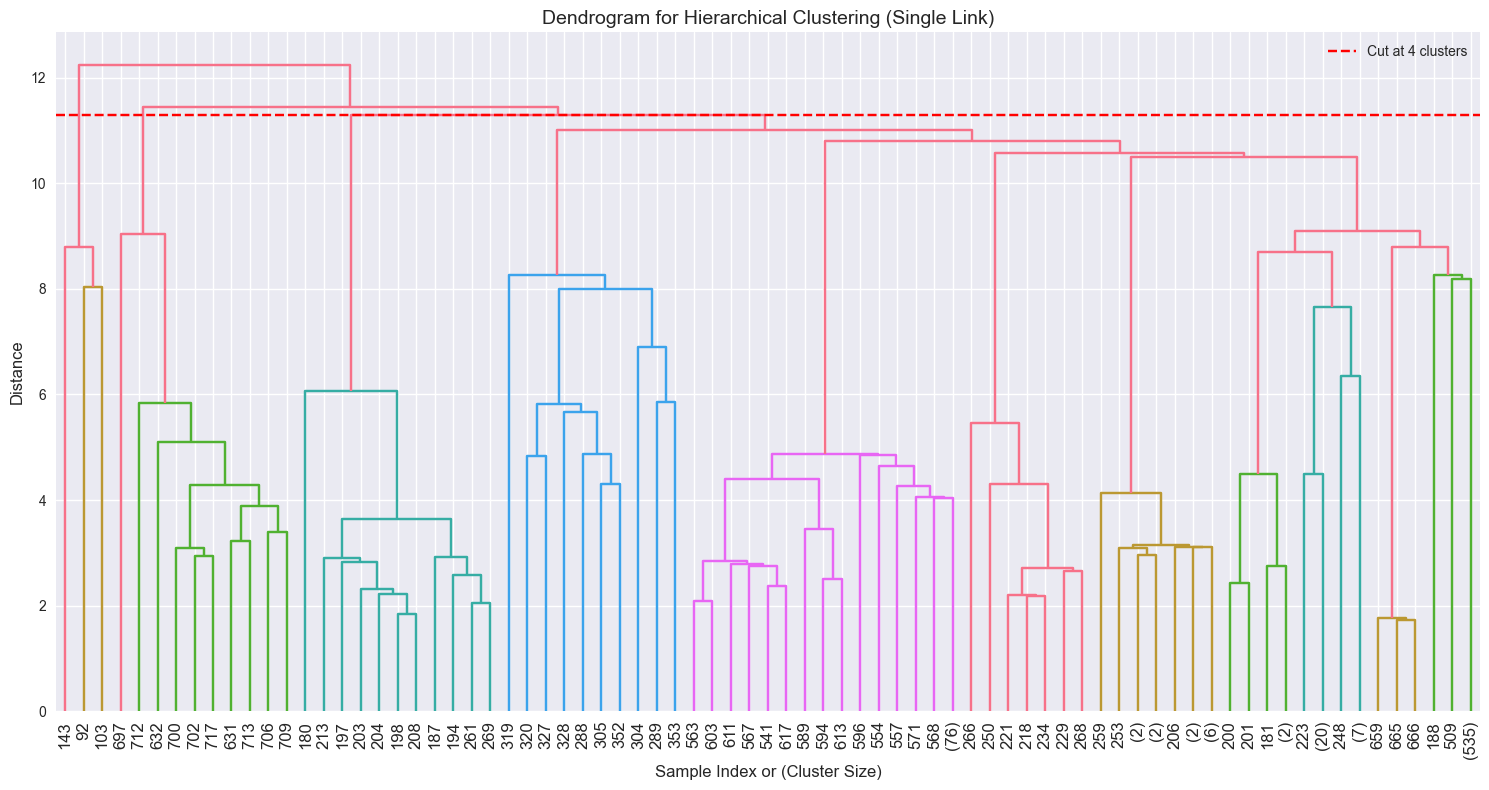

In [8]:
linkage_matrix = linkage(X_scaled, method="single", metric="euclidean")

plt.figure(figsize=(15, 8))
dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=10,
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=12,
)
plt.title("Dendrogram for Hierarchical Clustering (Single Link)", fontsize=14)
plt.xlabel("Sample Index or (Cluster Size)", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.axhline(
    y=linkage_matrix[-optimal_k + 1, 2],
    color="r",
    linestyle="--",
    label=f"Cut at {optimal_k} clusters",
)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
X_scaled_gmm = X_scaled.astype(np.float64)

gmm = GaussianMixture(
    n_components=optimal_k,
    random_state=42,
    n_init=10,
    reg_covar=1e-6,  # Add regularization to prevent singular covariance matrices
    covariance_type="full",  # Use full covariance matrices
)
gmm_labels = gmm.fit_predict(X_scaled_gmm)

gmm_silhouette = silhouette_score(X_scaled_gmm, gmm_labels)

print(f"Silhouette Score: {gmm_silhouette:.4f}")
print(f"Log Likelihood: {gmm.score(X_scaled_gmm) * len(X_scaled_gmm):.2f}")
unique, counts = np.unique(gmm_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"\tCluster {cluster}: {count} samples")

Silhouette Score: 0.2808
Log Likelihood: 193744.81
	Cluster 0: 269 samples
	Cluster 1: 278 samples
	Cluster 2: 100 samples
	Cluster 3: 73 samples


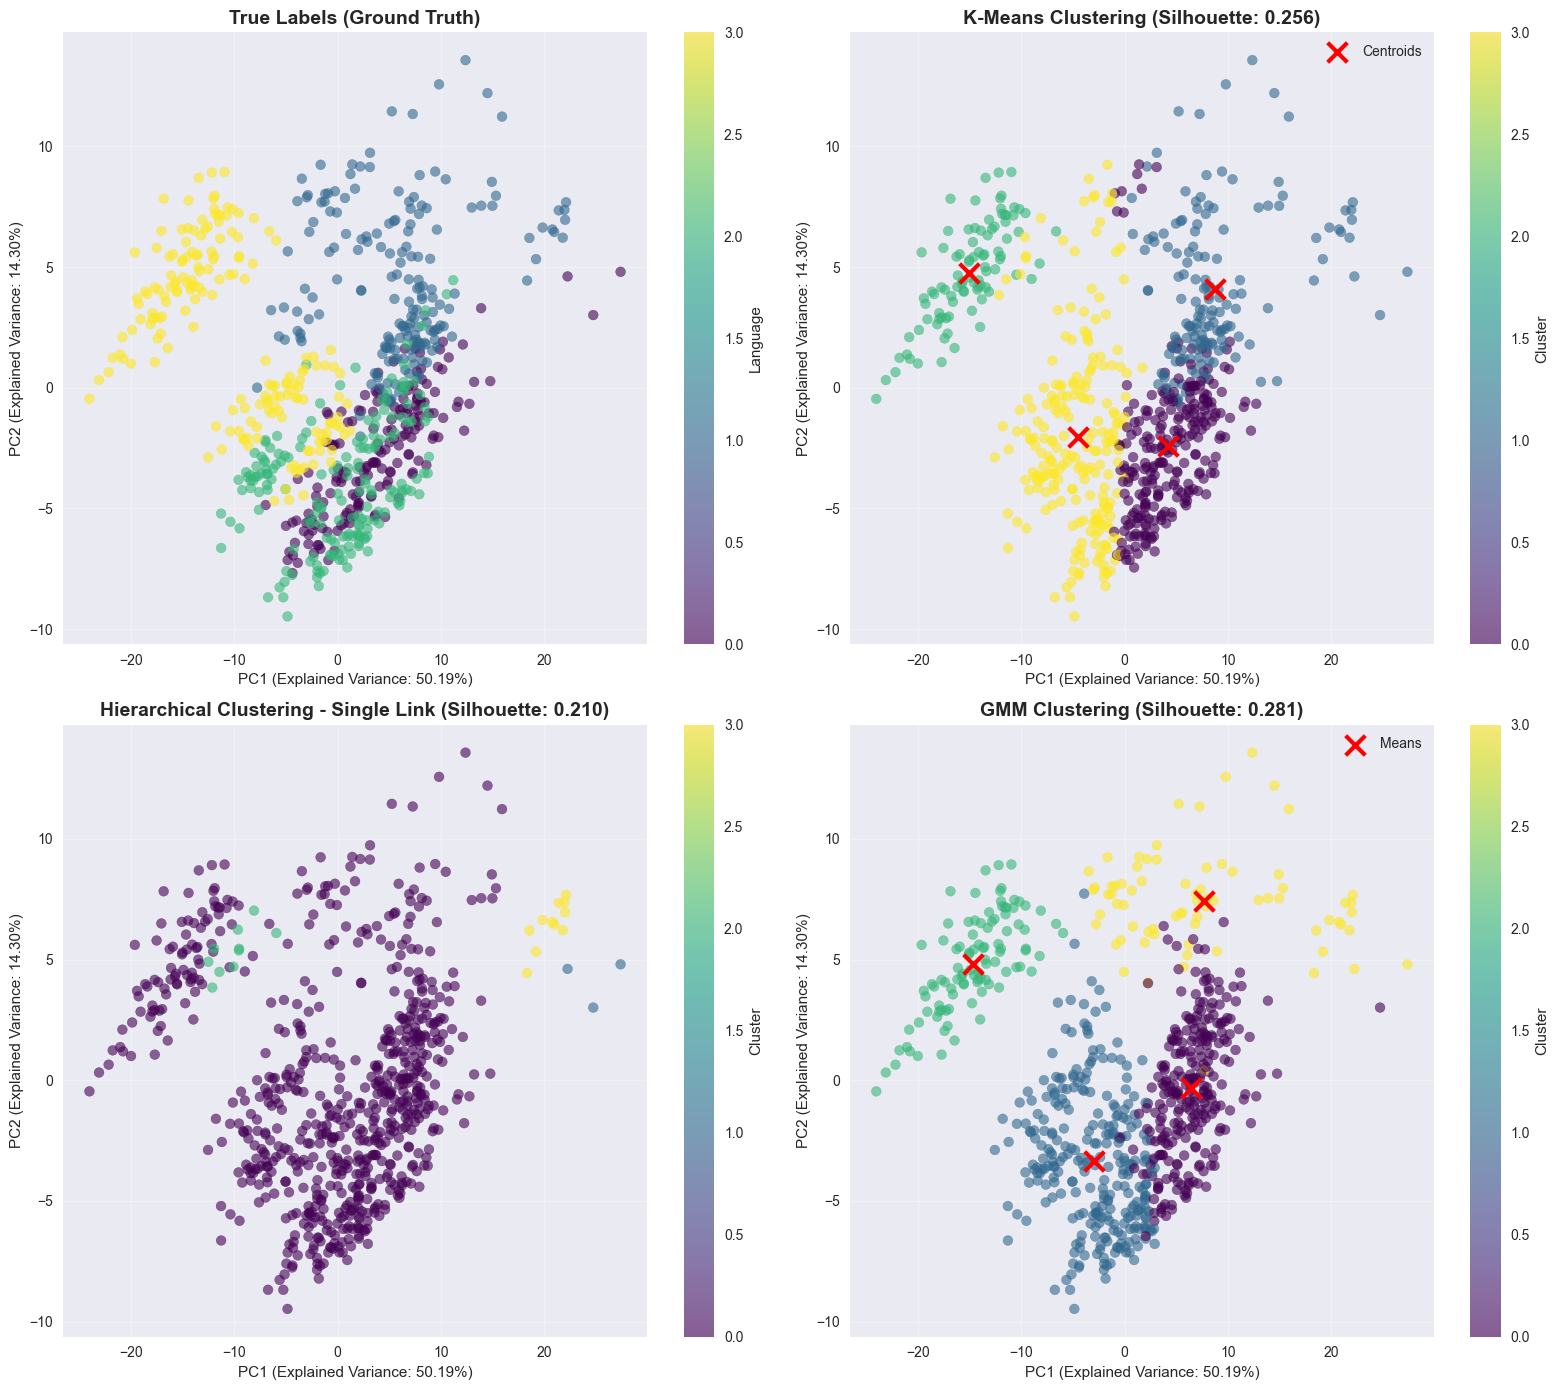


Total explained variance by first 2 principal components: 64.50%


In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# True labels
scatter1 = axes[0, 0].scatter(
    X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="viridis", alpha=0.6, s=50
)
axes[0, 0].set_title("True Labels (Ground Truth)", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel(
    f"PC1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})"
)
axes[0, 0].set_ylabel(
    f"PC2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})"
)
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label="Language")

# K-Means
scatter2 = axes[0, 1].scatter(
    X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="viridis", alpha=0.6, s=50
)
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0, 1].scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    c="red",
    marker="x",
    s=200,
    linewidths=3,
    label="Centroids",
)
axes[0, 1].set_title(
    f"K-Means Clustering (Silhouette: {kmeans_silhouette:.3f})",
    fontsize=14,
    fontweight="bold",
)
axes[0, 1].set_xlabel(
    f"PC1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})"
)
axes[0, 1].set_ylabel(
    f"PC2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})"
)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
plt.colorbar(scatter2, ax=axes[0, 1], label="Cluster")

# Hierarchical
scatter3 = axes[1, 0].scatter(
    X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap="viridis", alpha=0.6, s=50
)
axes[1, 0].set_title(
    f"Hierarchical Clustering - Single Link (Silhouette: {hierarchical_silhouette:.3f})",
    fontsize=14,
    fontweight="bold",
)
axes[1, 0].set_xlabel(
    f"PC1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})"
)
axes[1, 0].set_ylabel(
    f"PC2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})"
)
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label="Cluster")

scatter4 = axes[1, 1].scatter(
    X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap="viridis", alpha=0.6, s=50
)
gmm_means_scaled = gmm.means_
gmm_means_pca = pca.transform(gmm_means_scaled)
axes[1, 1].scatter(
    gmm_means_pca[:, 0],
    gmm_means_pca[:, 1],
    c="red",
    marker="x",
    s=200,
    linewidths=3,
    label="Means",
)
axes[1, 1].set_title(
    f"GMM Clustering (Silhouette: {gmm_silhouette:.3f})", fontsize=14, fontweight="bold"
)
axes[1, 1].set_xlabel(
    f"PC1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})"
)
axes[1, 1].set_ylabel(
    f"PC2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})"
)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
plt.colorbar(scatter4, ax=axes[1, 1], label="Cluster")

plt.tight_layout()
plt.show()

print(
    f"\nTotal explained variance by first 2 principal components: {pca.explained_variance_ratio_.sum():.2%}"
)

In [11]:
def analyze_cluster_composition(labels, method_name):
    print(method_name)
    print("-" * 60)
    for cluster_id in range(optimal_k):
        cluster_mask = labels == cluster_id
        cluster_languages = df.loc[cluster_mask, "language"]
        language_counts = cluster_languages.value_counts()
        print(f"\nCluster {cluster_id} ({np.sum(cluster_mask)} samples):")
        for lang, count in language_counts.items():
            percentage = (count / np.sum(cluster_mask)) * 100
            print(f"  {lang}: {count} ({percentage:.1f}%)")


analyze_cluster_composition(kmeans_labels, "K-Means")
analyze_cluster_composition(hierarchical_labels, "Hierarchical (Single Link)")
analyze_cluster_composition(gmm_labels, "GMM")

K-Means
------------------------------------------------------------

Cluster 0 (253 samples):
  German: 134 (53.0%)
  Korean: 102 (40.3%)
  Italian: 13 (5.1%)
  Spanish: 4 (1.6%)

Cluster 1 (152 samples):
  Italian: 139 (91.4%)
  German: 8 (5.3%)
  Korean: 5 (3.3%)

Cluster 2 (92 samples):
  Spanish: 92 (100.0%)

Cluster 3 (223 samples):
  Spanish: 84 (37.7%)
  Korean: 73 (32.7%)
  German: 38 (17.0%)
  Italian: 28 (12.6%)
Hierarchical (Single Link)
------------------------------------------------------------

Cluster 0 (696 samples):
  Korean: 180 (25.9%)
  German: 177 (25.4%)
  Spanish: 170 (24.4%)
  Italian: 169 (24.3%)

Cluster 1 (3 samples):
  German: 3 (100.0%)

Cluster 2 (10 samples):
  Spanish: 10 (100.0%)

Cluster 3 (11 samples):
  Italian: 11 (100.0%)
GMM
------------------------------------------------------------

Cluster 0 (269 samples):
  German: 109 (40.5%)
  Italian: 93 (34.6%)
  Korean: 67 (24.9%)

Cluster 1 (278 samples):
  Korean: 113 (40.6%)
  Spanish: 80 (28.8%)
  